In [1]:
from seaborn import palettes
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats import anova
from statsmodels.stats import multitest
from scipy import stats
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick

/Users/deyingli/miniconda3/envs/pytorch/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### 0. basic information

In [3]:
# read the fiber name
l_idx = [0,2,12,14,16,18,24,26,29,31,35,37,39,41,43,46,48,50,52,54,56,58,60,62,64,66,68,70]
m_idx = [4,5,6,7,8,9,10,11]
l_idx = np.array(l_idx)
m_idx = np.array(m_idx)
label_f = open('/Users/deyingli/Documents/code/multi_old/support_data/fiber_name_ori_nonum_nohemi.txt', 'r')
label_name = label_f.readlines()
label_name = [' '.join([i.strip() for i in price.strip().split('\n')]) for price in label_name]
label_name_lm = [label_name[l_idx[i]] for i in range(len(l_idx))] + [label_name[m_idx[i]] for i in range(len(m_idx))]
print(f'the number of fiber: {len(label_name_lm)}')

the number of fiber: 36


In [4]:
# color map
fiber_label_colormap = ['#bd706e', '#6181ad', '#cdcdc0', '#6181ad', '#6181ad'] # three colors
fiber_label = np.array([1,1,2,2,3, 3,3,3,3,3, # 10
                        3,3,1,1,4, 4,1,1,4,4, # 20
                        3,3,4,4,1, 1,1,1,4,2, # 30
                        2,4,4,4,4, 1,1,1,1,1, # 40
                        1,2,2,1,1, 3,2,2,2,2, # 50
                        2,2,2,2,2, 2,2,2,5,5, # 60
                        5,5,5,5,5, 5,5,5,5,5, # 70
                        5,5,])
fiber_label = fiber_label-1 # (71,)
fiber_label_lm = np.array(list(fiber_label[l_idx]) + list(fiber_label[m_idx]))
print(fiber_label_lm.shape) # (41,)
palette = [fiber_label_colormap[fiber_label_lm[i]] for i in range(len(label_name_lm))]
len(palette)

(36,)


36

### 1. plotting

In [5]:
datapath = './'

fibers = label_name_lm
colors = palette

In [6]:
# smooth data
x = pd.read_csv('./bismode_average_values_AveAlongMode_L1.csv')
fa = np.zeros((156,36))
for fi, ff in enumerate(label_name_lm):
    x_fiber = x[x['ModeName'] == f'Mode{fi+1}']
    fa[:, fi] = np.array(x_fiber['AvgModeValue'])
fa_ind = fa_ind = np.array([i for i in range(36)]).astype(np.int32)

In [7]:
print(fa_ind.shape, fa.shape)

(36,) (156, 36)


In [8]:
incression_rate = np.zeros(36)
_df = pd.read_csv(f'/Users/deyingli/Documents/code/R_dir/Trajectory/smoothed_curves_AveAlongMode_L1/final_paper_1st_10dis_smoothed_800.csv')
for i in range(1, 37):
    Modei_df = _df[_df['ModeName']==f'Mode{i}']
    Modei_Derivative = np.array(Modei_df['Derivative'])
    Modei_Derivative_mean = np.mean(Modei_Derivative)
    print(label_name_lm[i-1], Modei_Derivative_mean)
    incression_rate[i-1] = Modei_Derivative_mean

AF 0.5265615102721244
ATR 0.17826677634617183
CG 0.8062576835057229
CST 0.08251090403453454
MLF 0.6886320648669045
FPT -0.024467294694824972
IFO 0.36652895061615987
ILF 0.5764729163403017
OR 0.060063136587753
POPT 0.003267034470260999
SLF_I 0.3310415048644404
SLF_II 0.2878622696586034
SLF_III 0.5292107547130194
STR 0.2405253249789831
UF 0.7554471616869569
T_PREF 0.12234531620139111
T_PREM 0.033756873437797465
T_PREC 0.11813848747941086
T_POSTC 0.2244824004299803
T_PAR 0.1477746241047747
T_OCC 0.05678438110801355
ST_FO 0.340057779690851
ST_PREF 0.1873670798715197
ST_PREM 0.255461421052913
ST_PREC 0.1604944261052039
ST_POSTC 0.25257964591541454
ST_PAR 0.19978835716610024
ST_OCC 0.05178605538896976
CA 0.10464818838999677
CC_1 0.446316750389198
CC_2 0.08637557077768807
CC_3 0.036623851243626625
CC_4 0.05701968138972072
CC_5 0.08778723433963063
CC_6 0.15807445347622398
CC_7 0.04743514576447058


In [9]:
import statsmodels.stats.weightstats as st
from statannotations.Annotator import Annotator

def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

1.7143365467010534 0.11569913493018065
1.2054887961127612 0.2535352962330976
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Association vs. Commissural: Mann-Whitney-Wilcoxon test two-sided, P_val:5.759e-04 U_stat=6.900e+01
Commissural vs. Projection: Mann-Whitney-Wilcoxon test two-sided, P_val:4.493e-01 U_stat=6.100e+01
Association vs. Projection: Mann-Whitney-Wilcoxon test two-sided, P_val:4.447e-05 U_stat=1.690e+02


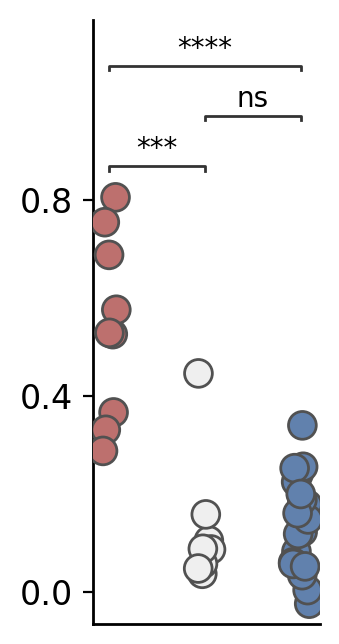

In [10]:
from matplotlib.pyplot import MultipleLocator
# difference between different type of fibers
fa_beta_1 = np.array([incression_rate[i] for i in [0,1,2,3,4,5,7,9,10]])
fa_beta_2 = np.array([incression_rate[i] for i in [6,20,23,24,25,27,32,33]])
fa_beta_3 = np.array([incression_rate[i] for i in [8,11,12,13,14,15,16,17,18,19,21,22,26,28,29,30,31,34,35]])
t,p_two,_ = st.ttest_ind(fa_beta_1, fa_beta_2,usevar='unequal')
print(t, p_two)
t,p_two,_ = st.ttest_ind(fa_beta_1, fa_beta_3,usevar='unequal')
print(t, p_two)

# plotting
df = pd.DataFrame(columns=['item', 'fiber', 'fiber type', 'Beta'])
for ii in range(len(label_name_lm)):
    #add row to end of DataFrame
    if fiber_label_lm[ii]==0: df.loc[len(df.index)] = [fiber_label_lm[ii], label_name_lm[ii], 'Association', incression_rate[ii]]
    if fiber_label_lm[ii]==2: df.loc[len(df.index)] = [fiber_label_lm[ii], label_name_lm[ii], 'Commissural', incression_rate[ii]]
    if fiber_label_lm[ii]==1 or fiber_label_lm[ii]==3 or fiber_label_lm[ii]==4: df.loc[len(df.index)] = [fiber_label_lm[ii], label_name_lm[ii], 'Projection', incression_rate[ii]]

np.random.seed(sum(map(ord, 'categorical')))
fiber_type = ['Association', 'Thalamo', 'Commissural', 'Projection', 'Stristo']
color = ['#bd706e', '#6181ad', '#efefef', '#6181ad', '#6181ad'] # three color

fig = plt.figure(figsize=(12,4), dpi=200)
fig.subplots_adjust(wspace=0.2)
ax = fig.add_subplot(171)
sns.stripplot(x='fiber type', y='Beta', 
            data=df,hue='item',
            size=10,
            palette=color,
            order=['Association', 'Commissural', 'Projection'],
            linewidth=1,
            jitter=True)

# ttest
pairs = [('Association','Projection'), ('Association','Commissural'), ('Commissural','Projection')]
annotator = Annotator(ax, pairs, data=df, x='fiber type', y='Beta',order=['Association', 'Commissural', 'Projection'])
annotator.configure(test='Mann-Whitney', text_format='star',line_height=0.01, line_width=1)
annotator.apply_and_annotate()

y_major_locator = MultipleLocator(0.4)
ax.yaxis.set_major_locator(y_major_locator)
plt.xticks([])
plt.xlabel('')
plt.ylabel('',fontsize=20) 
plt.yticks(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.get_legend().remove()

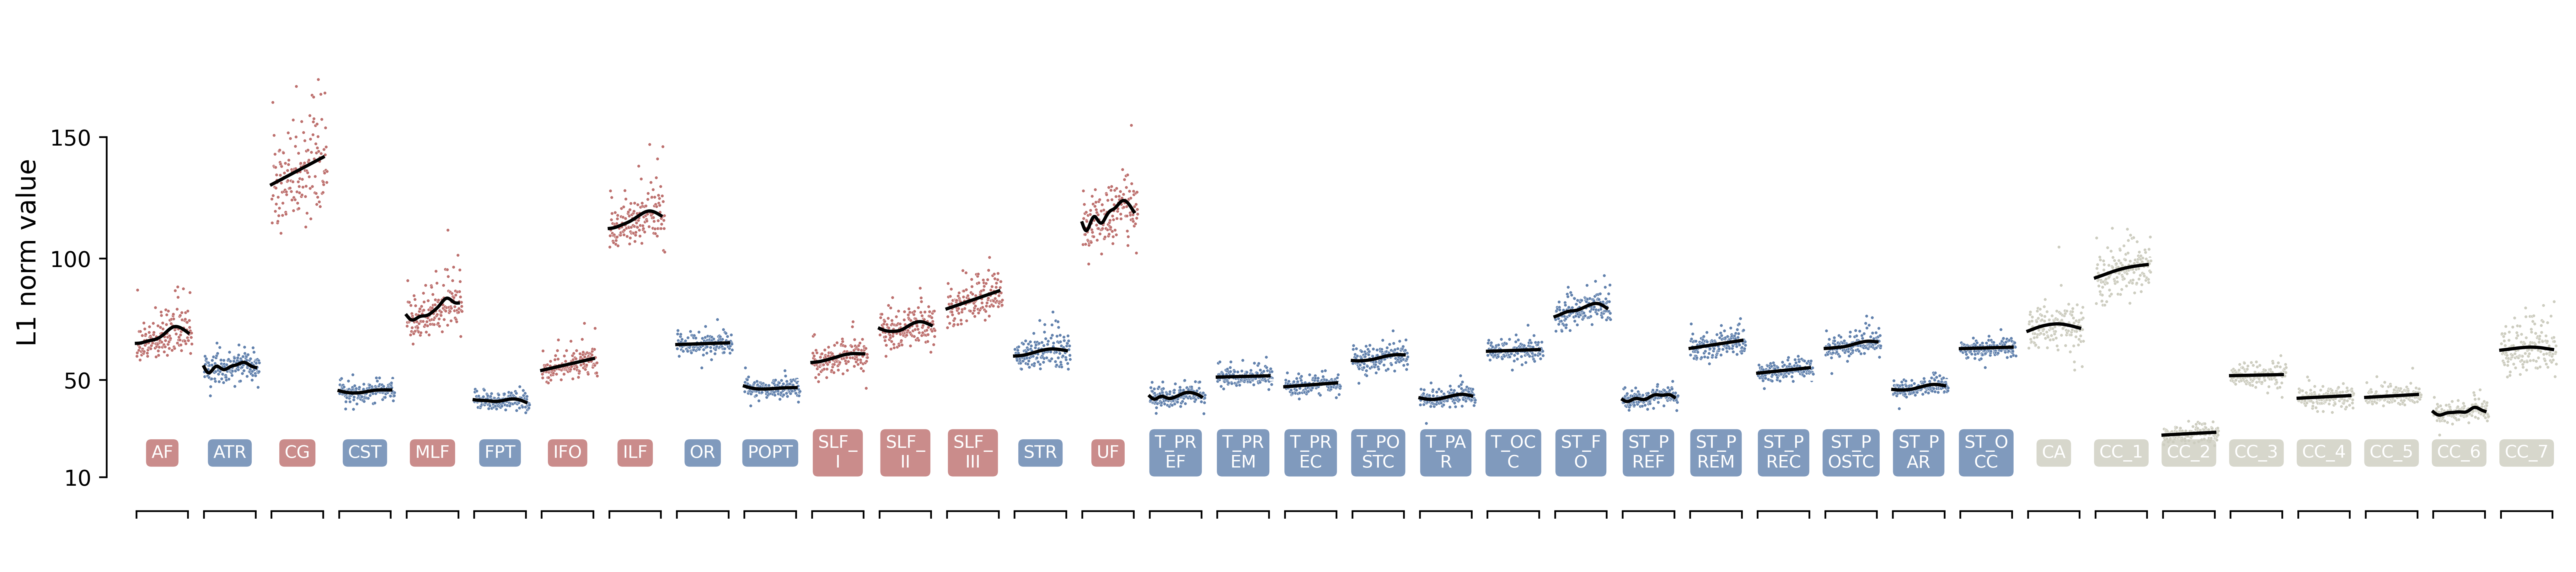

In [11]:
import textwrap
df_r = pd.read_csv('bismode_smoothed_values_L1norm_bin.csv')

num_roi = 36
x = np.array(x_fiber['Age'])

fig, axes = plt.subplots(nrows=1, ncols=num_roi, figsize=[20, 4], sharex=True, sharey=True, dpi=500) 
fig.subplots_adjust(wspace=0)
# 设置统一的标签框宽度
label_width = 4  # 每行最多10个字符，可以根据需要调整
for i in range(num_roi):
    
    # Smooth data from r
    df_ri = df_r[df_r['ModeName']==f'Mode{i+1}']
    df_ri_SmoothedValue = np.array(df_ri['SmoothedValue'])
    df_ri_age = np.array(df_ri['Age'])
    axes[i].plot(df_ri_age,df_ri_SmoothedValue, color='Black')

    # scatter plot
    sns.scatterplot(x=x, y=fa[:,i], s=2, marker='o', ax=axes[i], color=colors[fa_ind[i]])

    axes[i].set_xlim([6,23]) # age range
    axes[i].set_xticks([8, 21])
    axes[i].set_ylim([5, 200]) # L1 value range
    axes[i].set_yticks([10,50,100,150])
    axes[i].set_ylabel('L1 norm value', fontsize=12)
    if i != 0:
        sns.despine(offset=10, trim=True, ax=axes[i], left=True)
        # axes[i].set_xticks([])
        # axes[i].set_yticks([])
        axes[i].set_xticklabels([])
        axes[i].set_xlabel(f'{fibers[fa_ind[i]]}', color='#ffffff')
        axes[i].tick_params(colors='w', which='both', axis='y')
    else:
        sns.despine(offset=10, trim=True, ax=axes[i])
        # axes[i].set_xlabel('Age_in_years')
        axes[i].set_xlabel(f'{fibers[fa_ind[i]]}', color='#ffffff')

    # 在x轴上方添加带有底色的标签
    label_text = fibers[fa_ind[i]]
    wrapped_text = '\n'.join(textwrap.wrap(label_text, width=label_width))
    label_x = 14.5  # 设置标签的x坐标，具体值需要根据实际情况调整
    label_y = 20  # 设置标签的y坐标，使其位于图表上方
    axes[i].text(label_x, label_y, wrapped_text, ha='center', va='center', fontsize=8, color='white',
                 bbox=dict(facecolor=colors[fa_ind[i]], edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8))

plt.show() 

In [12]:
r2_df = pd.read_csv('/Users/deyingli/Documents/code/R_dir/Trajectory/cleaned_data_gam_1_2_L1_results.csv')
fa_beta = np.zeros(36)
fa_p    = np.zeros(36)
for i in range(36):
    fa_beta[i] = np.array(r2_df[r2_df['bundles']==f'Mode{i+1}']['partial_R2'])[0]
    fa_p[i] = np.array(r2_df[r2_df['bundles']==f'Mode{i+1}']['p_age_fdc_fdr'])[0]
fa_p

array([0.   , 0.003, 0.   , 0.003, 0.   , 0.155, 0.   , 0.   , 0.216,
       0.131, 0.   , 0.   , 0.   , 0.003, 0.   , 0.   , 0.476, 0.002,
       0.   , 0.   , 0.17 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.143, 0.155, 0.   , 0.037, 0.434, 0.214, 0.019, 0.   , 0.664])

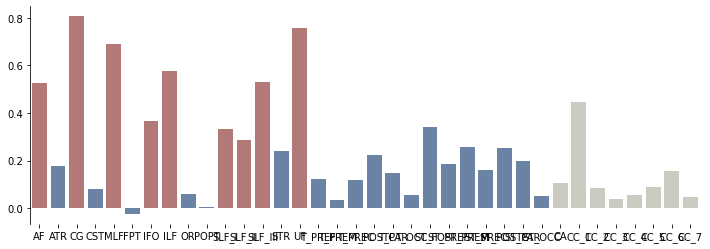

In [13]:
plt.figure(figsize=(12,4))
barplot = sns.barplot(x=label_name_lm, y=incression_rate, palette=palette)

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['top'].set_color('none')
plt.show()

In [14]:
fa_R2_linear = np.loadtxt('./TGC_deve_R2.txt')
fa_p_linear = np.loadtxt('./TGC_deve_p.txt')

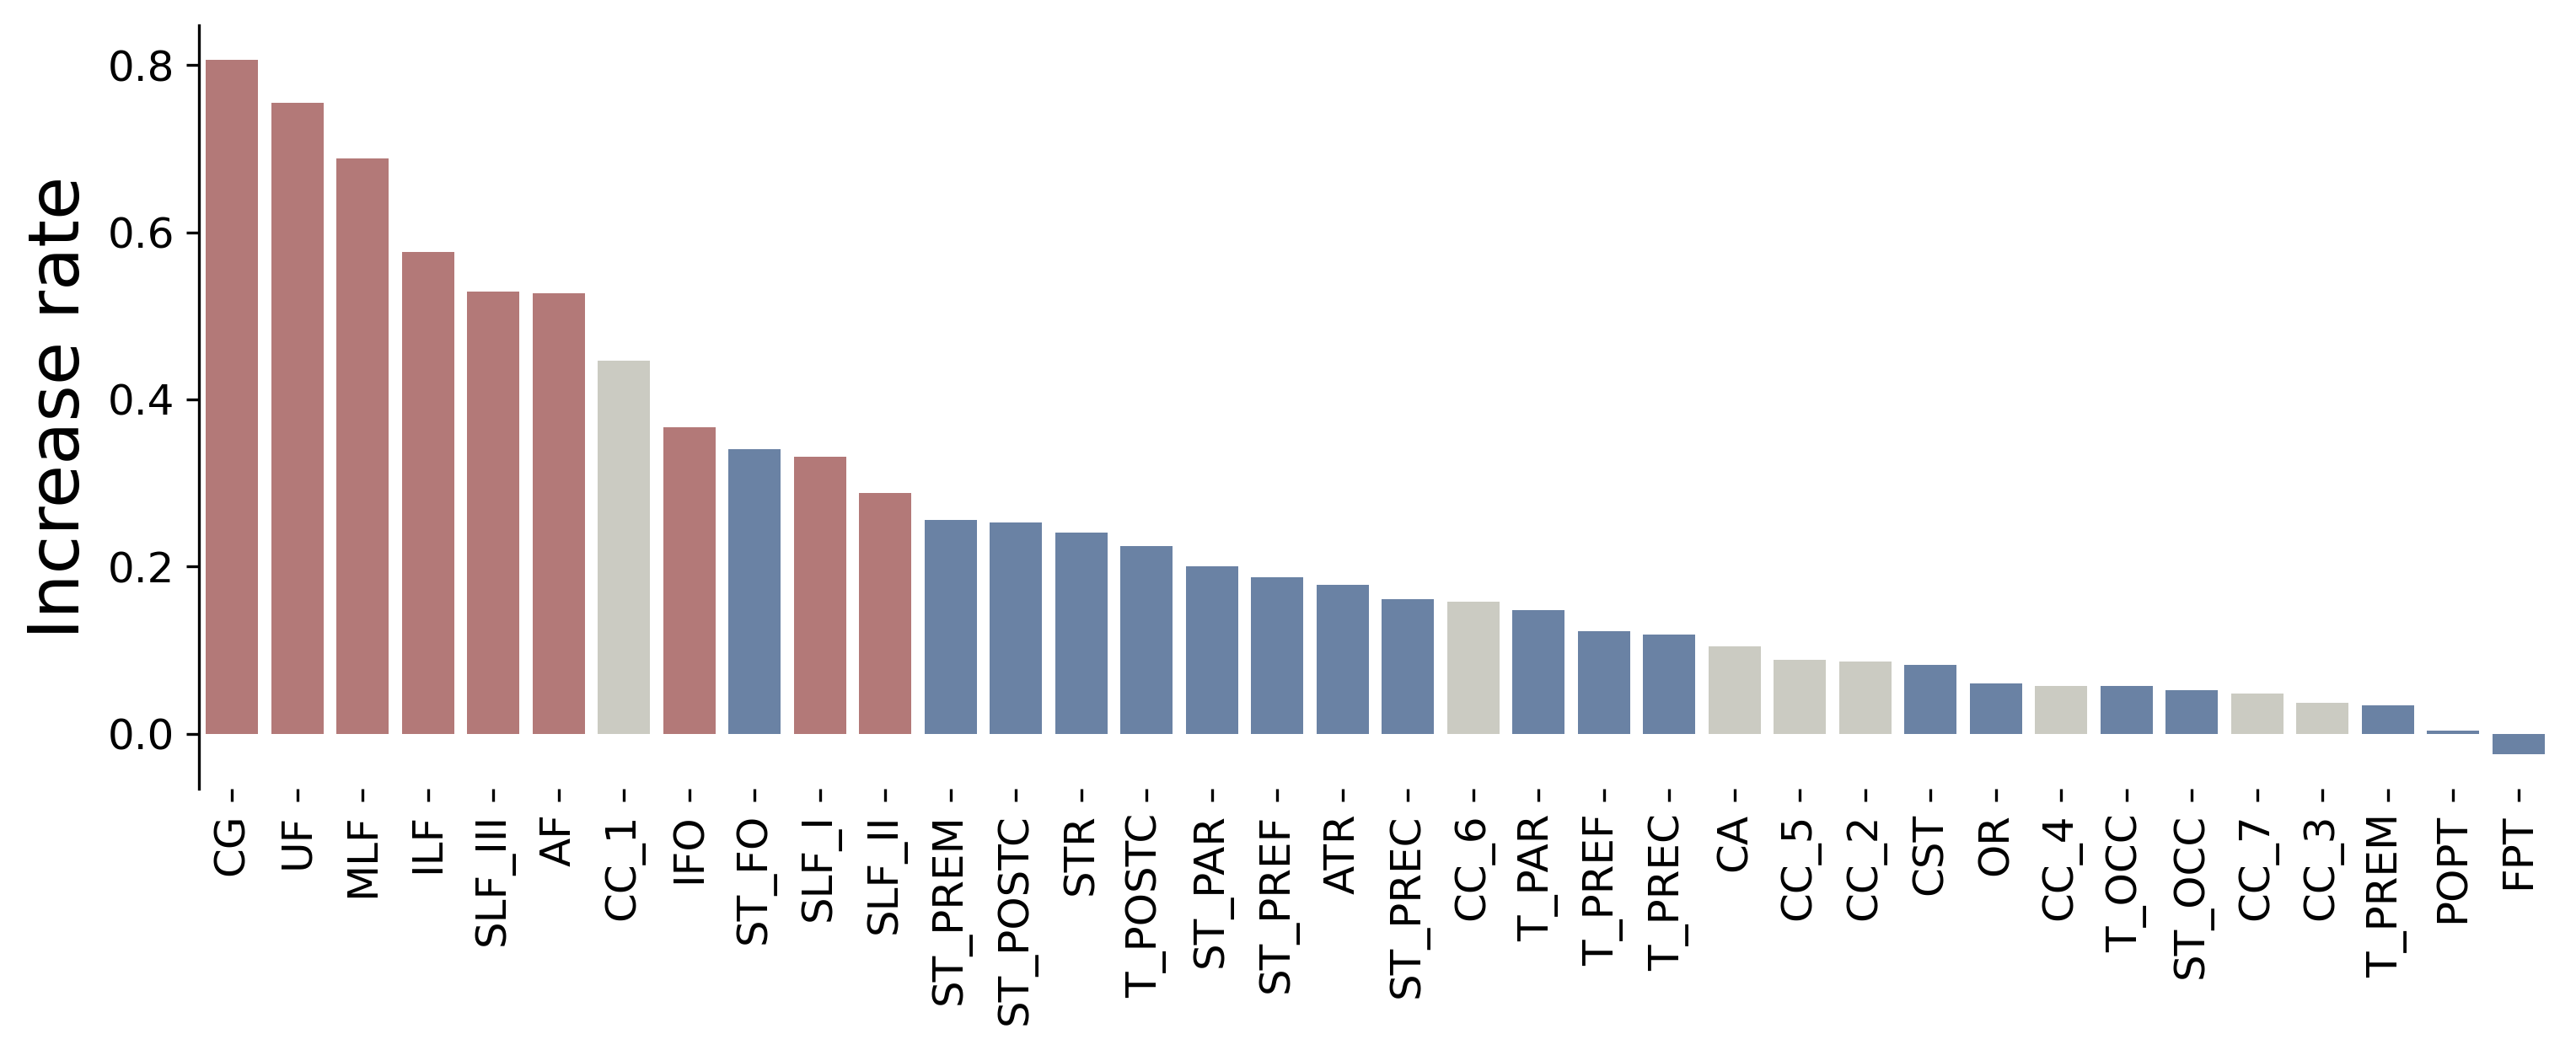

In [15]:
# rank
idx = np.argsort(incression_rate)[::-1] # 按照增长程度排序
fa_beta_sorted = np.array([incression_rate[idx[i]] for i in range(36)])
palette_sorted = [palette[idx[i]] for i in range(36)]
label_name_lm_sorted = [label_name_lm[idx[i]] for i in range(36)]

plt.figure(figsize=(12,4), dpi=300)
barplot = sns.barplot(x=label_name_lm_sorted, y=fa_beta_sorted, palette=palette_sorted)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Increase rate', fontsize=20)

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['top'].set_color('none')

# p *
# fa_p_sorted = np.array([fa_p[idx[i]] for i in range(36)])
# for ii in range(36):
#     if   fa_p_sorted[ii]<0.001: plt.text(ii,fa_beta_sorted[ii]+0.01, '***', ha='center', fontsize=12)
#     elif fa_p_sorted[ii]<0.01:  plt.text(ii,fa_beta_sorted[ii]+0.01, '**',  ha='center', fontsize=12)
#     elif fa_p_sorted[ii]<0.05:  plt.text(ii,fa_beta_sorted[ii]+0.01, '*',   ha='center', fontsize=12)
plt.show()

In [14]:
fa_sorted = np.array([fa[:,idx[i]] for i in range(36)]).T
fibers = label_name_lm_sorted
colors = palette_sorted
fa_sorted.shape

(156, 36)

In [15]:
from pygam import LinearGAM, s, f

In [16]:
idx

array([ 2, 14,  4,  7, 12,  0, 29,  6, 21, 10, 11, 23, 25, 13, 18, 26, 22,
        1, 24, 34, 19, 15, 17, 28, 33, 30,  3,  8, 32, 20, 27, 35, 31, 16,
        9,  5])

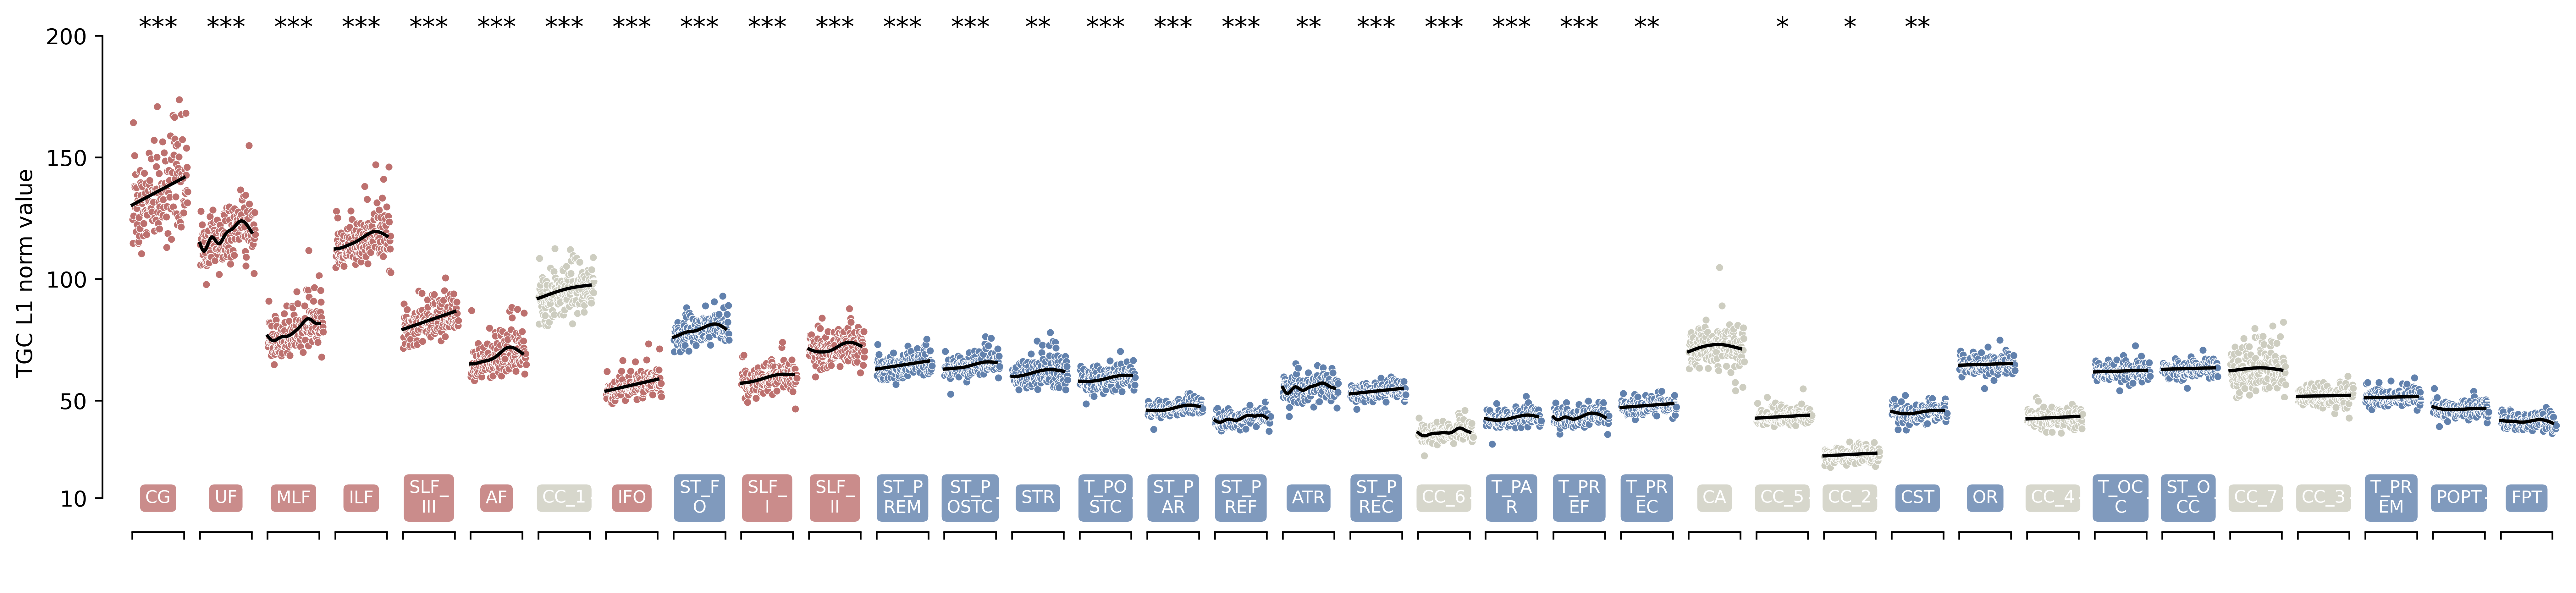

In [22]:
import textwrap
df_r = pd.read_csv('bismode_smoothed_values_L1norm_bin.csv')

num_roi = 36
x = np.array(x_fiber['Age'])

fig, axes = plt.subplots(nrows=1, ncols=num_roi, figsize=[20, 4], sharex=True, sharey=True, dpi=500) 
fig.subplots_adjust(wspace=0)
# 设置统一的标签框宽度
label_width = 4  # 每行最多10个字符，可以根据需要调整
for i in range(num_roi):
    sns.scatterplot(x=x, y=fa_sorted[:,i], s=12, marker='o', ax=axes[i], color=colors[fa_ind[i]])

    # Smooth data from r
    df_ri = df_r[df_r['ModeName']==f'Mode{idx[i]+1}']
    df_ri_SmoothedValue = np.array(df_ri['SmoothedValue'])
    df_ri_age = np.array(df_ri['Age'])
    axes[i].plot(df_ri_age,df_ri_SmoothedValue, color='Black')

    axes[i].set_xlim([6,23]) # age range
    axes[i].set_xticks([8, 21])
    axes[i].set_ylim([5, 200]) # L1 value range
    axes[i].set_yticks([10,50,100,150,200])
    axes[i].set_ylabel('TGC L1 norm value')
    if i != 0:
        sns.despine(offset=10, trim=True, ax=axes[i], left=True)
        axes[i].set_xticklabels([])
        axes[i].set_xlabel(f'{fibers[fa_ind[i]]}', color='#ffffff')
        axes[i].tick_params(colors='w', which='both', axis='y')
    else:
        sns.despine(offset=10, trim=True, ax=axes[i])
        axes[i].set_xlabel(f'{fibers[fa_ind[i]]}', color='#ffffff')

    # 在x轴上方添加带有底色的标签
    label_text = fibers[fa_ind[i]]
    wrapped_text = '\n'.join(textwrap.wrap(label_text, width=label_width))
    label_x = 14.5  # 设置标签的x坐标，具体值需要根据实际情况调整
    label_y = 10  # 设置标签的y坐标，使其位于图表上方
    axes[i].text(label_x, label_y, wrapped_text, ha='center', va='center', fontsize=8, color='white',
                 bbox=dict(facecolor=colors[fa_ind[i]], edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8))
    
    label_x = 14.5  # 设置标签的x坐标，具体值需要根据实际情况调整
    label_y = 200  # 设置标签的y坐标，使其位于图表上方

    # # 在图最上面添加R2的值
    # label_text = f'r2={np.round(fa_beta[fa_ind[i]], 3)}'
    # axes[i].text(label_x, label_y, label_text, ha='center', va='center', fontsize=8, color='black', rotation=45,
    #              bbox=dict(facecolor='w', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8))

    # p *
    fa_p_sorted = np.array([fa_p[idx[i]] for i in range(36)])
    if   fa_p_sorted[i]<0.001: axes[i].text(label_x,label_y, '***', ha='center', fontsize=12)
    elif fa_p_sorted[i]<0.01:  axes[i].text(label_x,label_y, '**',  ha='center', fontsize=12)
    elif fa_p_sorted[i]<0.05:  axes[i].text(label_x,label_y, '*',   ha='center', fontsize=12)

plt.show() 